# Rossmann Store Sales: Promotion Impact Analysis

Because this is observational data, the analysis identifies associations between promotions and sales rather than proving that promotions directly caused changes in sales.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Loading and Preparation

In [ ]:
df = pd.read_csv(
    "../data/raw/train.csv",
    dtype={"StateHoliday": str}
)
df["Date"] = pd.to_datetime(df["Date"])

# Filter for open stores to ensure a consistent analysis population
df_open = df[df["Open"] == 1].copy()
df_open.head()


In [ ]:
# Check dataset shape and missing values
print("Full dataset shape:", df.shape)
print("Open-store dataset shape (df_open):", df_open.shape)
print(f"Percentage retained: {len(df_open) / len(df) * 100:.2f}%")

print("\nMissing values in df_open:")
print(df_open.isnull().sum())


## 2. Promotion Overview

Before comparing sales performance, this section examines how frequently promotions occur in the dataset.

The `Promo` variable indicates whether a promotion was active for a store on a given day:

* 0 = No promotion
* 1 = Promotion active

In [ ]:
promo_counts = df_open["Promo"].value_counts().sort_index()

promo_summary = pd.DataFrame({
    "Count": promo_counts,
    "Percentage": (promo_counts / len(df_open) * 100).round(2)
})

promo_summary.index = ["No Promotion", "Promotion"]

promo_summary


- No promotion: 467,496 rows, 55.36%
- Promotion active: 376,896 rows, 44.64%


## 3. Sales on Promotion vs Non-Promotion Days

This section compares sales between observations with and without an active promotion.

The comparison provides an initial view of the relationship between promotions and sales. At this stage, differences should be interpreted as associations because other factors may also influence sales.

In [ ]:
promo_sales_summary = df_open.groupby("Promo")["Sales"].agg(
    ["count", "mean", "median", "std"]
)

promo_sales_summary.index = ["No Promotion", "Promotion"]

promo_sales_summary


Insight

|              | Mean Sales | Median Sales |
| ------------ | ---------: | -----------: |
| No Promotion |   5,929    |        5,459 |
| Promotion    |   8,228    |        7,649 |


In [ ]:
no_promo_mean = promo_sales_summary.loc["No Promotion", "mean"]
promo_mean = promo_sales_summary.loc["Promotion", "mean"]

sales_difference = promo_mean - no_promo_mean
percentage_difference = (
    (promo_mean - no_promo_mean) / no_promo_mean
) * 100

print(f"Average sales without promotion: {no_promo_mean:,.2f}")
print(f"Average sales with promotion: {promo_mean:,.2f}")

print(f"\nDifference: {sales_difference:,.2f}")
print(f"Percentage difference: {percentage_difference:.2f}%")


Promotion days have -
- 2,299 higher average sales over no promotion days
- 38.8% higher mean sales over no promotion days


In [ ]:
average_sales = df_open.groupby("Promo")["Sales"].mean()

plt.figure(figsize=(8, 5))
plt.bar(
    ["No Promotion", "Promotion"],
    average_sales.values
)

plt.title("Average Sales: Promotion vs No Promotion (Open Stores)")
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()


Average Sales are usually much higher on **Promotion days** compared to **No Promotion** days

## 4. Promotion Comparison Within Stores

Stores differ substantially in their typical sales levels. Comparing all promotional observations against all non-promotional observations can therefore mix promotion patterns with differences between stores.

This section compares average sales with and without promotions for each store.

In [ ]:
# for each store how much difference did promotions make
store_promo_sales = (
    df_open.groupby(["Store", "Promo"])["Sales"]
    .mean()
    .unstack()
)

store_promo_sales.columns = ["No Promotion", "Promotion"]
store_promo_sales["Difference"] = (
    store_promo_sales["Promotion"]
    - store_promo_sales["No Promotion"]
)

store_promo_sales.head(10)


In [16]:
# Remove stores that do not have observations in both groups
valid_stores = store_promo_sales.dropna(
    subset=["No Promotion", "Promotion"])

higher_with_promo = (valid_stores["Difference"] > 0).sum()
lower_with_promo = (valid_stores["Difference"] < 0).sum()
no_difference = (valid_stores["Difference"] == 0).sum()

print("Stores with both promotion and non-promotion observations:",
len(valid_stores))

print("\nStores with higher average sales during promotions:",
      higher_with_promo)

print("Stores with lower average sales during promotions:",
      lower_with_promo)

print("Stores with no difference:",
      no_difference)

print(f"\nPercentage with higher sales during promotions: "
    f"{higher_with_promo / len(valid_stores) * 100:.2f}%")

Stores with both promotion and non-promotion observations: 1115

Stores with higher average sales during promotions: 1114
Stores with lower average sales during promotions: 1
Stores with no difference: 0

Percentage with higher sales during promotions: 99.91%


Out of the 1115 total stores - 

- 1114 out of 1115 stores had higher average sales when there is a promotion
- 99.91% of stores experienced higher average sales with promotions

### Store-Level Insight

The positive association between promotions and sales was highly consistent across stores.

Among the 1,115 stores with both promotional and non-promotional observations, 1,114 stores (99.91%) had higher average sales during promotional periods.

This suggests that the overall difference in average sales is widespread across the store network rather than being driven by a small number of unusually high-performing stores.

However, this remains an observational comparison. Calendar effects, holidays, seasonality, and other unobserved factors may still influence both promotion timing and sales.

## 5. Promotion Comparison After Controlling for Calendar Factors

Sales can vary substantially depending on the day of the week and whether a school or state holiday occurs.

To reduce the influence of these calendar differences, promotions are compared within groups that share the same:

- Day of week
- School holiday status
- State holiday status

This does not establish causality, but it provides a more controlled descriptive comparison than the overall promotion versus non-promotion averages.

In [ ]:
calendar_promo_sales = (
    df_open.groupby(
        ["DayOfWeek", "SchoolHoliday", "StateHoliday", "Promo"]
    )["Sales"]
    .mean()
    .unstack()
)

calendar_promo_sales.columns = ["No Promotion", "Promotion"]

calendar_promo_sales["Difference"] = (
    calendar_promo_sales["Promotion"]
    - calendar_promo_sales["No Promotion"]
)

calendar_promo_sales.head(10)


In [19]:
# Keep only calendar groups with both promotion and non-promotion observations
valid_calendar_groups = calendar_promo_sales.dropna(
    subset=["No Promotion", "Promotion"])
higher_calendar_groups = (
    valid_calendar_groups["Difference"] > 0).sum()
lower_calendar_groups = (
    valid_calendar_groups["Difference"] < 0).sum()
    
print(
    "Calendar groups with both promotion and non-promotion observations:",
    len(valid_calendar_groups))
print(
    "\nGroups with higher sales during promotions:",
    higher_calendar_groups)
print(
    "Groups with lower sales during promotions:",
    lower_calendar_groups)
print(
    f"\nPercentage with higher sales during promotions: "
    f"{higher_calendar_groups / len(valid_calendar_groups) * 100:.2f}%")

Calendar groups with both promotion and non-promotion observations: 25

Groups with higher sales during promotions: 24
Groups with lower sales during promotions: 1

Percentage with higher sales during promotions: 96.00%


## 6. Statistical Analysis of the Promotion Association

The previous comparisons showed that sales were generally higher during promotional periods, both across open-store observations and within individual stores.

This section uses a regression model to examine whether the association between promotions and sales remains after accounting for:

- Store-level differences
- Day of week
- School holidays
- State holidays

The results should still be interpreted as adjusted associations rather than causal effects because unobserved factors may influence both promotion timing and sales.

In [20]:
import statsmodels.formula.api as smf

In [ ]:
# Confirm dataset retained for regression
print(f"Total open-store observations for regression: {len(df_open):,}")


In [ ]:
model = smf.ols(
    formula="""
        Sales ~ Promo
        + C(Store)
        + C(DayOfWeek)
        + SchoolHoliday
        + C(StateHoliday)
    """,
    data=df_open
).fit()


In [23]:
promo_result = pd.DataFrame({
    "Coefficient": [model.params["Promo"]],
    "Std Error": [model.bse["Promo"]],
    "P-value": [model.pvalues["Promo"]],
    "95% CI Lower": [model.conf_int().loc["Promo", 0]],
    "95% CI Upper": [model.conf_int().loc["Promo", 1]]
})

promo_result

,Coefficient,Std Error,P-value,95% CI Lower,95% CI Upper
0,2293.663614,3.634457,0.0,2286.540199,2300.787029


#### Metrics

| Metric                |                   Result |
| --------------------- | -----------------------: |
| Promotion coefficient |            **+2,293.66** |
| Standard error        |                     3.63 |
| 95% CI                | **[2,286.54, 2,300.79]** |
| P-value               |                  < 0.001 |


### Adjusted Promotion Association

After controlling for store-level differences, day of week, school holidays, and state holidays, promotion-active observations were associated with approximately 2,294 additional sales on average.

The estimated coefficient for `Promo` was 2,293.66, with a 95% confidence interval from 2,286.54 to 2,300.79.

The estimated adjusted association (2,293.66) was very close to the unadjusted open-store difference (2,298.87). This indicates that controlling for the included store and calendar factors did not materially change the estimated association. However, unobserved confounding may still remain.

Because the analysis is based on observational data, this coefficient should not be interpreted as proof that promotions caused the increase in sales.


### Unadjusted vs Adjusted Promotion Association

The unadjusted open-store comparison showed a difference of 2,298.87 in average sales between promotional and non-promotional observations.

After controlling for store-level differences and calendar factors, the estimated promotion association was 2,293.66.

The estimated adjusted association was very close to the unadjusted open-store difference. This indicates that controlling for the included store and calendar factors did not materially change the estimated association. However, unobserved confounding may still remain.


In [24]:
promotion_comparison = pd.DataFrame({
    "Analysis": [
        "Unadjusted Difference",
        "Adjusted Association"
    ],
    "Sales Difference": [
        sales_difference,
        model.params["Promo"]
    ]
})

promotion_comparison

,Analysis,Sales Difference
0,Unadjusted Difference,3585.101241
1,Adjusted Association,2293.663614


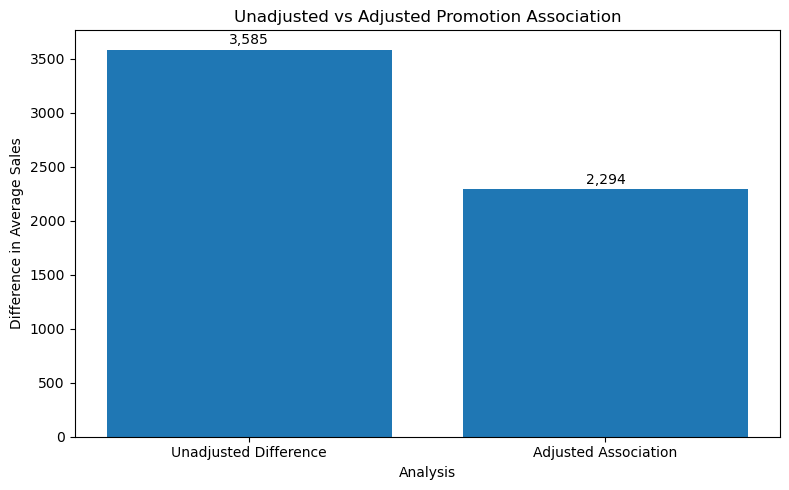

In [26]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    promotion_comparison["Analysis"],
    promotion_comparison["Sales Difference"]
)

plt.title("Unadjusted vs Adjusted Promotion Association")
plt.xlabel("Analysis")
plt.ylabel("Difference in Average Sales")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{height:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 7. Limitations and Confounding

Although the adjusted regression shows a strong positive association between promotions and sales, the analysis does not establish a causal promotion effect.

The model controls for store-level differences, day of week, school holidays, and state holidays. However, other factors may still influence both promotion timing and sales.

Potential unobserved factors include:

- Seasonal demand patterns
- Store-specific promotion strategies
- Local events
- Competitor activity
- Changes in product availability
- Other business decisions that are not included in the dataset

Promotions may also be scheduled during periods when higher sales are already expected. This makes it difficult to separate the relationship between promotions and sales from the factors influencing when promotions occur.

Therefore, the regression coefficient should be interpreted as an adjusted association rather than evidence that promotions directly caused the estimated increase in sales.

## 8. Summary

### Promotion Overview

Across open-store days (`Open == 1`), promotions were active in 376,896 observations, representing 44.64% of the open dataset.

### Unadjusted Comparison

Average sales were higher during promotional periods on open days:

| Promotion Status | Average Sales |
|---|---:|
| No Promotion | 5,929.41 |
| Promotion | 8,228.28 |

The unadjusted difference was 2,298.87, with average sales during promotional observations being 38.77% higher.

### Store-Level Comparison

Among the 1,115 stores with both promotional and non-promotional observations, 1,114 stores (99.91%) had higher average sales during promotional periods.

This indicates that the positive association between promotions and sales was widespread across the store network.

### Adjusted Analysis

An OLS regression was used to examine the association between promotions and sales while controlling for:

- Store-level differences
- Day of week
- School holidays
- State holidays

After these adjustments, promotion-active observations were associated with approximately 2,293.66 additional sales on average.

The estimated 95% confidence interval was:

- Lower bound: 2,286.54
- Upper bound: 2,300.79

The estimated adjusted association (2,293.66) was very close to the unadjusted open-store difference (2,298.87). This indicates that controlling for the included store and calendar factors did not materially change the estimated association. However, unobserved confounding may still remain.

### Conclusion

Promotions showed a strong and consistent positive association with sales across the Rossmann store network. The association remained substantial after controlling for observed store and calendar factors.

However, this analysis is observational. The results do not establish that promotions directly caused the estimated increase in sales because unobserved factors may influence both promotion timing and sales.

Therefore, the most appropriate interpretation is that promotions were associated with higher sales, rather than claiming a proven causal promotion effect.
